# Second Encoder

The primary change here will be the separation criteria that we will use, rather than just ionization mode we will also differentiate by instrument type. 

In [2]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

### Data Upload and basic processing

In [3]:
# The 5/20 dataset with rat based toxicity data
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()

(4001, 16)


,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group
0,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','63.0228:0.177223 65.0386:5.629055 68.0495:0.4...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','90 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
1,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','63.0228:0.125979 65.0386:2.113734 68.0495:0.6...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','75 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
2,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','56.0496:0.115017 65.0386:0.970445 68.0495:1.0...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','60 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
3,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','51.0229:0.102992 56.0495:0.143820 65.0386:0.6...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','45 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'
4,'C#CCN(C)Cc1ccccc1','555-57-7','C11H13N','159.104799416','160.1121','[M+H]+','56.0496:0.482623 65.0385:0.377829 68.0495:2.5...,'positive','LC-ESI-QFT','Q Exactive Orbitrap Thermo Scientific','30 (nominal)','C#CCN(C)Cc1ccccc1','',273.642508,'mg/kg','Q-Orbitrap-positive'


In [4]:
# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'N/A'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")
df3.head()

["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]


,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group
0,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.177223 65.0386:5.629055 68.0495:0.45...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,90 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
1,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.125979 65.0386:2.113734 68.0495:0.68...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,75 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
2,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.115017 65.0386:0.970445 68.0495:1.03...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,60 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
3,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,51.0229:0.102992 56.0495:0.143820 65.0386:0.67...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,45 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
4,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.482623 65.0385:0.377829 68.0495:2.59...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,30 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive


In [5]:
print(df3['Group'].nunique()) # 13
# 13 groups means a 13 way split
print(df3['Group'].unique())
# Now we want counts of each group
print(df3['Group'].value_counts())

13
['Q-Orbitrap-positive' 'Q-Orbitrap-negative' 'Q-TOF-positive'
 'LTQ-Orbitrap-positive' 'QQQ-positive' 'Q-TOF-negative'
 'LTQ-Orbitrap-negative' 'QQQ-negative' 'Other-positive' 'LTQ-negative'
 'QQQ-nan' 'LTQ-positive' 'Other-negative']
Group
Q-Orbitrap-positive      1307
Q-Orbitrap-negative       756
Q-TOF-positive            736
LTQ-Orbitrap-positive     481
QQQ-positive              253
Q-TOF-negative            188
QQQ-negative               85
Other-positive             71
LTQ-Orbitrap-negative      63
LTQ-positive               19
QQQ-nan                    18
Other-negative             13
LTQ-negative               11
Name: count, dtype: int64


### Data Split

This split is a little bit less straightfoward since we need to divide into many many classes rather than just two so we will need a more rigorous naming system in place.

Notice that in this case we needn't do a positive negative split since that split is aready included inthe group differentiation.
- Q-Orbitrap-positive      1307 --> QQpos
- Q-Orbitrap-negative       756 --> QQneg
- Q-TOF-positive            736 --> QTOFpos
- LTQ-Orbitrap-positive     481 --> LTQOpos
- QQQ-positive              253 --> QQQpos
- Q-TOF-negative            188 --> QTOFneg
- QQQ-negative               85 --> QQQneg
- Other-positive             71 --> Opos
- LTQ-Orbitrap-negative      63 --> LTQOneg
- LTQ-positive               19 --> LTQpos
- QQQ-nan                    18 --> QQQnan
- Other-negative             13 --> Oneg
- LTQ-negative               11 --> LTQneg

As before we will need to convert spectra strings to dataframes that we can then bin.

In [6]:
# Data split based on the 'Group' column
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307
df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive '] # 736  
df3_LTQOpos = df3[df3['Group'] == 'TQ-Orbitrap-positive'] # 481
df3_QQQpos = df3[df3['Group'] == 'QQQ-positive'] # 253
df3_QTOFneg = df3[df3['Group'] == 'Q-TOF-negative'] # 188 

# With these there may not be enough data to train a model
df3_QQQneg = df3[df3['Group'] == 'QQQ-negative'] # 85
df3_Opos = df3[df3['Group'] == 'Other-positive'] # 71
df3_LTQOneg = df3[df3['Group'] == 'LTQ-Orbitrap-negative'] # 63
df3_LTQpos = df3[df3['Group'] == 'LTQ-positive'] # 19
df3_QQQnan = df3[df3['Group'] == 'QQQ-nan'] # 18
df3_Oneg = df3[df3['Group'] == 'Other-negative'] # 13
df3_LTQneg = df3[df3['Group'] == 'LTQ-negative'] # 11

In [7]:
# First define the function we will use
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

In [8]:
df3_QQpos.head()

,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group
0,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.177223 65.0386:5.629055 68.0495:0.45...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,90 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
1,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.125979 65.0386:2.113734 68.0495:0.68...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,75 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
2,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.115017 65.0386:0.970445 68.0495:1.03...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,60 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
3,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,51.0229:0.102992 56.0495:0.143820 65.0386:0.67...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,45 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive
4,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.482623 65.0385:0.377829 68.0495:2.59...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,30 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive


### Binning

In [9]:
# First lets include the binning functions
# Binning the spectra data 
def bin_spectra_by_integer_mz(df):
    """
    Bins the spectra data by rounding m/z (column names) to the nearest integer,
    then sums intensities for duplicate integer bins.
    Assumes first column is SMILES, rest are m/z columns (floats).
    """
    smiles_col = df.columns[0]
    spectra = df.iloc[:, 1:]
    # Map each column to its integer bin
    int_mz = [int(round(float(c))) for c in spectra.columns]
    spectra.columns = int_mz
    # Group columns by integer m/z and sum
    binned = spectra.groupby(level=0, axis=1).sum()
    # Add the SMILES column back
    binned.insert(0, smiles_col, df[smiles_col])
    return binned

# Fill in the missing integer columns 
def fill_missing_integer_columns(df):
    """
    Ensures all integer columns from 1 to the maximum are present in the DataFrame.
    Missing columns are filled with zeros.
    Assumes the first column is the label (e.g., SMILES).
    """
    # Get the integer columns (skip the first column)
    int_cols = [col for col in df.columns[1:] if isinstance(col, int)]
    #min_col = min(int_cols)
    max_col = max(int_cols)
    all_int_cols = list(range(1, max_col + 1))
    # Find missing columns
    missing_cols = set(all_int_cols) - set(int_cols)
    # Add missing columns with zeros
    for col in missing_cols:
        df[col] = 0.0
    # Reorder columns: first column, then sorted integer columns
    ordered_cols = [df.columns[0]] + sorted(all_int_cols)
    df = df[ordered_cols]
    return df

In [10]:
df3_QQpos_matrix = spectrum_string_to_dataframe(df3_QQpos,'Spectrum', 'SMILES_spectra')
df3_QQpos_spectra = df3_QQpos_matrix

In [11]:
# Assume df3_QQpos_spectra is your DataFrame
cols = df3_QQpos_spectra.columns.tolist()
# Keep the first column as is, convert the rest to float
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_QQpos_spectra.columns = new_cols

In [12]:
# Convert all elements except the first column to float
df3_QQpos_spectra.iloc[:, 1:] = df3_QQpos_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

In [13]:
all_float = all(isinstance(c, float) for c in df3_QQpos_spectra.columns[1:])
print("All columns are float:", all_float)

# Select all columns except the first
spectra = df3_QQpos_spectra.iloc[:, 1:]

# Check if every element is a float
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)

All columns are float: True
All elements are float: True


In [14]:
# Here we will sort the columns so the m/z values are in ascending order
# Sort columns by float value, keep the first column (SMILES) first
# For negative ionization mode
cols = df3_QQpos_spectra.columns.tolist()
sorted_cols = [cols[0]] + sorted(cols[1:], key=float)
df3_QQpos_spectra = df3_QQpos_spectra[sorted_cols]

In [15]:
# Look at the column maximums
max_col_pos = max(df3_QQpos_spectra.columns[1:])
print("Largest column name (m/z):", max_col_pos)
max_col_neg = max(df3_QQpos_spectra.columns[1:])
print("Largest column name (m/z):", max_col_neg)

# Look at the column minimums
min_col_pos = min(df3_QQpos_spectra.columns[1:])
print("Smallest column name (m/z):", min_col_pos)
min_col_neg = min(df3_QQpos_spectra.columns[1:])
print("Smallest column name (m/z):", min_col_neg)

Largest column name (m/z): 679.4382
Largest column name (m/z): 679.4382
Smallest column name (m/z): 49.5027114573
Smallest column name (m/z): 49.5027114573


In [16]:
# Use the binning function on the df3_QQpos_spectra mode spectra
binned_df3_QQpos_spectra = bin_spectra_by_integer_mz(df3_QQpos_spectra)
binned_df3_QQpos_spectra_filled = fill_missing_integer_columns(binned_df3_QQpos_spectra)
binned_df3_QQpos_spectra_filled.head()

/tmp/ipykernel_1013378/954985155.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  binned.insert(0, smiles_col, df[smiles_col])
/tmp/ipykernel_1013378/954985155.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = 0.0
/tmp/ipykernel_1013378/954985155.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = 

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,670,671,672,673,674,675,676,677,678,679
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# Save the binned spectra to a CSV file
#binned_df3_QQpos_spectra_filled.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv", index=False)

### ChemNet data

In [18]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [19]:
ChemNet_of_df3_QQpos_no_repeats_dict = get_chemnet_emb_from_smiles(df3_QQpos_spectra["SMILES_spectra"])

/home/dlipsey/.local/lib/python3.8/site-packages/fcd_torch/fcd.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  keras_config = torch.load(model_path)


In [20]:
ChemNet_of_df3_QQpos_no_repeats = pd.DataFrame.from_dict(ChemNet_of_df3_QQpos_no_repeats_dict, orient='index')
ChemNet_of_df3_QQpos_no_repeats.reset_index(inplace=True)
ChemNet_of_df3_QQpos_no_repeats.rename(columns={'index': 'SMILES'}, inplace=True)

In [21]:
# Save ChemNet embeddings to a CSV file
#ChemNet_of_df3_QQpos_no_repeats.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv", index=False)

## Encoder: Functions and architecture

In [22]:
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-1]

    #chem_encodings = spectra_dataset.iloc[:,-8:]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    #chem_encodings_tensor = torch.Tensor(chem_encodings.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

In [23]:
# Training and validation dataset split for the positive ionization mode
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
# Count occurrences of each SMILES_spectra
counts = df3_QQpos_spectra['SMILES_spectra'].value_counts()
# Keep only SMILES_spectra with at least 4 entries
valid_smiles = counts[counts >= 4].index
filtered_df3_QQpos_spectra = df3_QQpos_spectra[df3_QQpos_spectra['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_df3_QQpos_spectra.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_df3_QQpos_spectra.loc[train_indices].reset_index(drop=True)
test_data = filtered_df3_QQpos_spectra.loc[test_indices].reset_index(drop=True)

# Add an 'index' column for downstream compatibility
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

train_data.head()
print(type(train_data))
train_data_copy = train_data.copy()
print(type(train_data_copy))
print(train_data['SMILES_spectra'].value_counts())

(609, 681)
(579, 681)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
SMILES_spectra
CN1N(C(=O)C=C1C)C1=CC=CC=C1                14
OCC(O)C(O)C(O)CO                           13
CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2         11
CCN(CC)CCNC(=O)C1=CC(Cl)=C(N)C=C1OC        11
CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1    11
                                           ..
CCN(CC)CC(=O)NC1=C(C)C=CC=C1C               3
CCN1C2=C(C=CC=C2)C2=C1C=CC(N)=C2            3
CCNC1=NC(NC(C)C)=NC(OC)=N1                  3
CCSCC1=C(OC(=O)NC)C=CC=C1                   3
CC1=CN([C@@H]2O[C@H](CO)C=C2)C(=O)NC1=O     2
Name: count, Length: 166, dtype: int64


In [24]:
# Input the Encoder file
#%% 
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

#%% 
# This cell needs to be updated with your own paths/requirements
batch_size = 64

# Train and validation datasets are determined by the above code
train_data = train_data
# train_data = pd.read_csv("/") 
val_data = test_data
# val_data = pd.read_csv(" ") 

# Chemical names and ChemNet embeddings
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 10

In [25]:
#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Encoder: Training

In [26]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model = train_model(
    model=encoder,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 24203.0 MB
  Memory Used: 14.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


/tmp/ipykernel_1013378/3365415882.py:37: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)


Epoch [1/500]
   Training loss: 0.08986936807632447
   Validation loss: 0.015097776427865028
Epoch [2/500]
   Training loss: 0.08136050775647163
   Validation loss: 0.012684625573456287
Epoch [3/500]
   Training loss: 0.0715532585978508
   Validation loss: 0.01246883999556303
Epoch [4/500]
   Training loss: 0.06617275923490525
   Validation loss: 0.011731259524822235
Epoch [5/500]
   Training loss: 0.06460179835557937
   Validation loss: 0.011830346658825874
Epoch [6/500]
   Training loss: 0.06390244998037815
   Validation loss: 0.011313962750136852
Epoch [7/500]
   Training loss: 0.0638293344527483
   Validation loss: 0.011763117276132107
Epoch [8/500]
   Training loss: 0.06358299888670445
   Validation loss: 0.011653500609099865
Epoch [9/500]
   Training loss: 0.06341368854045867
   Validation loss: 0.011469916440546513
Epoch [10/500]
   Training loss: 0.06340512372553349
   Validation loss: 0.011574036441743374
Epoch [11/500]
   Training loss: 0.0632703211158514
   Validation loss: 

In [27]:
# Encoder excecution
encoder.eval()
with torch.no_grad():
    test_output = encoder(x_val)  # output.shape will be (batch_size, 512)

with torch.no_grad():
    train_output = encoder(x_train)  # output.shape will be (batch_size, 512)

### PCA Plots of encoder outputs

In [28]:
# Mapping from SMILES to Response
smiles_to_response = df3_QQpos.drop_duplicates(subset='SMILES_spectra').set_index('SMILES_spectra')['Response']

# Ouptput dataframe
test_output_np = test_output.cpu().numpy()
test_output_df = pd.DataFrame(test_output_np)
test_output_df['SMILES_spectra'] = test_data['SMILES_spectra'].values  # 1:1 with test_data
cols = test_output_df.columns.tolist()
test_output_df = test_output_df[['SMILES_spectra'] + [c for c in cols if c != 'SMILES_spectra']]
test_output_df['Response'] = test_output_df['SMILES_spectra'].map(smiles_to_response)

# Check the output
print(test_output_df.shape)
print(test_output_df['SMILES_spectra'].value_counts())

(579, 514)
SMILES_spectra
CN1N(C(=O)C=C1C)C1=CC=CC=C1                       13
OCC(O)C(O)C(O)CO                                  13
OCC(O)C(O)C(O)C(O)CO                              10
CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2                10
CCN(CC)CCNC(=O)C1=CC(Cl)=C(N)C=C1OC               10
                                                  ..
COC1=CC=CC=C1NC(=O)C1=CC2=C(C=CC=C2)C=C1O          2
ClCCNP1(=O)OCCCN1CCCl                              2
ClC1=CC=CC(=C1)N1CCN(CCCN2N=C3C=CC=CN3C2=O)CC1     2
CCCCC(CC)COC(=O)C1=CC=CC=C1C(O)=O                  2
CCN(CC)CC(=O)NC1=C(C)C=CC=C1C                      2
Name: count, Length: 166, dtype: int64


In [29]:
test_output_df.head()

,SMILES_spectra,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
0,C#CCN(C)Cc1ccccc1,-0.100676,-0.017248,-0.092198,0.360848,0.002704,0.082267,-0.097392,-0.632139,-0.634828,...,0.757104,0.757270,0.008671,-0.200175,-0.284159,-0.560199,0.018016,0.048257,0.209070,273.642508
1,C#CCN(C)Cc1ccccc1,-0.108233,-0.022008,-0.104259,0.350395,0.015602,0.073920,-0.101548,-0.632505,-0.643177,...,0.747046,0.768214,0.011741,-0.217539,-0.301335,-0.550310,0.039908,0.039693,0.204734,273.642508
2,C#CCN(C)Cc1ccccc1,-0.100537,-0.017830,-0.090214,0.375927,0.000133,0.086919,-0.109509,-0.643687,-0.631393,...,0.750474,0.759512,0.013012,-0.199091,-0.287189,-0.564244,0.031161,0.050255,0.212711,273.642508
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.261001,0.069551,0.392016,0.664629,-0.026734,0.125092,-0.351373,0.146257,0.023326,...,-0.431264,0.576908,-0.030772,-0.035420,0.098289,-0.040144,0.232435,0.094728,0.074940,5000.000000
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,-0.123280,0.063091,0.118423,0.147183,0.001573,0.053245,0.023537,-0.194300,-0.051134,...,-0.100601,0.167577,-0.223779,0.174654,0.088891,-0.151185,-0.023399,0.088878,-0.095863,5000.000000


In [30]:
# Ouptput dataframe
train_output_np = train_output.cpu().numpy()
train_output_df = pd.DataFrame(train_output_np)
train_output_df['SMILES_spectra'] = train_data_copy['SMILES_spectra'].values  # 1:1 with test_data
cols = train_output_df.columns.tolist()
train_output_df = train_output_df[['SMILES_spectra'] + [c for c in cols if c != 'SMILES_spectra']]
train_output_df['Response'] = train_output_df['SMILES_spectra'].map(smiles_to_response)

# Check the output
print(train_output_df.shape)
print(train_output_df['SMILES_spectra'].value_counts())

(609, 514)
SMILES_spectra
CN1N(C(=O)C=C1C)C1=CC=CC=C1                14
OCC(O)C(O)C(O)CO                           13
CNCCCN1C2=C(CCC3=C1C=CC=C3)C=CC=C2         11
CCN(CC)CCNC(=O)C1=CC(Cl)=C(N)C=C1OC        11
CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1    11
                                           ..
CCN(CC)CC(=O)NC1=C(C)C=CC=C1C               3
CCN1C2=C(C=CC=C2)C2=C1C=CC(N)=C2            3
CCNC1=NC(NC(C)C)=NC(OC)=N1                  3
CCSCC1=C(OC(=O)NC)C=CC=C1                   3
CC1=CN([C@@H]2O[C@H](CO)C=C2)C(=O)NC1=O     2
Name: count, Length: 166, dtype: int64


In [31]:
train_output_df.head()

,SMILES_spectra,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
0,C#CCN(C)Cc1ccccc1,-0.095442,-0.021367,-0.064732,0.410140,-0.028272,0.098173,-0.120848,-0.608028,-0.603265,...,0.741309,0.725708,0.007104,-0.165164,-0.259890,-0.540024,-0.009421,0.055468,0.220990,273.642508
1,C#CCN(C)Cc1ccccc1,-0.103750,-0.018175,-0.100014,0.347172,0.011610,0.077845,-0.094250,-0.634234,-0.642861,...,0.753383,0.765975,0.009615,-0.210781,-0.292286,-0.558386,0.033220,0.044238,0.205323,273.642508
2,C#CCN(C)Cc1ccccc1,-0.099255,-0.017267,-0.090438,0.373969,-0.000168,0.086806,-0.108220,-0.644698,-0.631448,...,0.750914,0.759509,0.013164,-0.198768,-0.285426,-0.565399,0.033554,0.051620,0.211616,273.642508
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.344626,-0.010933,0.121179,0.623130,-0.105321,0.118909,-0.419458,-0.023406,-0.008629,...,-0.355441,0.439651,0.002791,0.134815,0.157557,0.334312,0.600713,0.152455,0.384411,5000.000000
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.347047,-0.010156,0.124084,0.620914,-0.105010,0.117900,-0.414624,-0.022360,-0.008938,...,-0.351819,0.440486,0.004299,0.133033,0.159702,0.332747,0.602188,0.149756,0.385511,5000.000000


In [32]:
# Find SMILES_spectra with 'occurances' or fewer/more occurrences
occurances = 10 # This can be changed

# Combine train and test for counting
all_smiles = pd.concat([train_output_df['SMILES_spectra'], test_output_df['SMILES_spectra']])
all_counts = all_smiles.value_counts()
selected_smiles = all_counts[all_counts >= occurances].index # More than or equal to 'occurances'
# selected_smiles = all_counts[all_counts <= occurances].index # Less than or equal to 'occurances'

# Subset both train and test to only those SMILES
train_output_df_sub = train_output_df[train_output_df['SMILES_spectra'].isin(selected_smiles)].copy()
test_output_df_sub = test_output_df[test_output_df['SMILES_spectra'].isin(selected_smiles)].copy()

print(train_output_df_sub['SMILES_spectra'].nunique())
print(test_output_df_sub['SMILES_spectra'].nunique())
print(train_output_df_sub.shape)
print(test_output_df_sub.shape)
print("Number of unique SMILES_spectra in train:", train_output_df_sub['SMILES_spectra'].nunique())
print("Number of unique SMILES_spectra in test:", test_output_df_sub['SMILES_spectra'].nunique())


18
18
(155, 514)
(146, 514)
Number of unique SMILES_spectra in train: 18
Number of unique SMILES_spectra in test: 18


In [33]:
# Upload the Chemnet embeddings dataframe to provide true embeddings 
ChemNet_of_df3_QQpos_no_repeats = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

# Get the unique SMILES_spectra for the subset
sub_smiles_set = set(test_output_df_sub['SMILES_spectra'].unique()) # With a unique dataframe this isn't strictly necessary

# Subset ChemNet_of_df2pos_no_repeats to only those SMILES
chemnet_sub = ChemNet_of_df3_QQpos_no_repeats[ChemNet_of_df3_QQpos_no_repeats['SMILES'].isin(sub_smiles_set)].copy()

# Merge with the Response column from df2 to get toxicity values
chemnet_sub = chemnet_sub.merge(
    df3[['SMILES_spectra', 'Response']],
    left_on='SMILES',
    right_on='SMILES_spectra',
    how='left'
)
# Remove the SMILES_spectra column after merging as it's redundant
chemnet_sub = chemnet_sub.drop(columns=['SMILES_spectra'])

# Keep only one row per unique SMILES (first occurrence)
chemnet_sub= chemnet_sub.drop_duplicates(subset='SMILES').copy()

# Check
print(chemnet_sub.shape)
chemnet_sub.head()


(18, 514)


,SMILES,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
0,C=C(C)C1CC=C(C)CC1,-0.116176,0.002966,-0.023850,-0.103578,-0.038338,0.042710,-0.245518,-0.157546,-0.201870,...,-0.082871,0.135509,0.000010,-0.498958,-0.144333,0.012490,-0.220284,0.061193,-0.347721,4825.080312
16,CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12,-0.596011,0.012174,-0.218746,0.144652,-0.009223,0.035933,-0.010077,-0.082254,-0.453001,...,0.933405,0.003413,-0.011088,0.026218,-0.015641,-0.085272,0.388240,0.057477,0.563751,400.000000
58,CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1,0.196781,0.008724,-0.294192,-0.471313,-0.281907,0.136417,-0.378564,-0.379551,-0.036421,...,0.019482,0.902094,-0.000209,-0.130971,-0.126209,-0.417062,0.312234,0.127192,0.182647,12500.000000
109,CC1=CC(=O)OC2=C1C=CC(O)=C2,0.320358,0.005968,-0.541099,0.010104,-0.225100,0.035888,0.343417,0.109103,-0.006698,...,-0.256850,0.933564,-0.000021,0.006631,-0.023242,-0.445357,0.339883,0.245815,-0.026356,3850.000000
134,CCCCCCCC(=O)OCC(COC(=O)CCCCCCC)OC(=O)CCCCCCC,0.291447,0.011824,-0.107934,-0.429980,-0.458429,0.391239,0.048168,-0.126499,-0.195105,...,-0.082579,0.009040,-0.000008,-0.057635,-0.005315,0.186953,0.186397,-0.268054,0.111695,33276.635020


In [34]:
# Create tox_epa12 column based on Response
test_output_df_sub['tox_epa12'] = (test_output_df_sub['Response'] <= 500).astype(int)
train_output_df_sub['tox_epa12'] = (train_output_df_sub['Response'] <= 500).astype(int)
chemnet_sub['tox_epa12'] = (chemnet_sub['Response'] <= 500).astype(int)

# Check the disribution
print(test_output_df_sub['tox_epa12'].value_counts())
print(train_output_df_sub['tox_epa12'].value_counts())
print(chemnet_sub['tox_epa12'].value_counts())

tox_epa12
0    122
1     24
Name: count, dtype: int64
tox_epa12
0    128
1     27
Name: count, dtype: int64
tox_epa12
0    15
1     3
Name: count, dtype: int64


### PCA plots

In [35]:
# Functions in plotting procedure
import matplotlib.cm as cm
import matplotlib.patches as mpatches


# Isolate the embedding columns
def get_embedding_columns(df):
    # Select all columns except the first and last by index
    return df.columns[1:-2].tolist()

# Outlier removal function after PCA
def remove_outliers_on_axes(df, pc1_col, pc2_col, n_low_pc1=0, n_high_pc1=0, n_low_pc2=0, n_high_pc2=0):
    # Remove outliers on PC2
    df = df.sort_values(pc2_col, ascending=True)
    if n_low_pc2 > 0:
        df = df.iloc[n_low_pc2:]
    if n_high_pc2 > 0:
        df = df.iloc[:-n_high_pc2]
    # Remove outliers on PC1
    df = df.sort_values(pc1_col, ascending=True)
    if n_low_pc1 > 0:
        df = df.iloc[n_low_pc1:]
    if n_high_pc1 > 0:
        df = df.iloc[:-n_high_pc1]
    return df


# Outlier removal function before PCA
def remove_outliers_by_column(df, col, n_low=0, n_high=0):
    df_sorted = df.sort_values(col, ascending=True)
    if n_high > 0:
        df_sorted = df_sorted.iloc[:-n_high]
    if n_low > 0:
        df_sorted = df_sorted.iloc[n_low:]
    return df_sorted

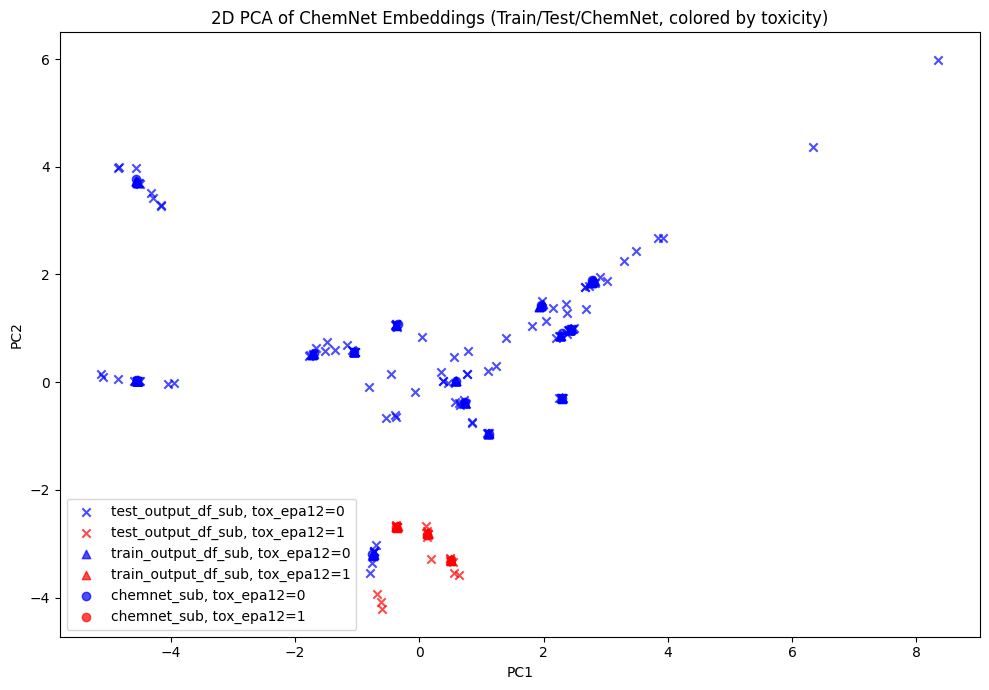

In [36]:
# PCA plot, color by toxicity (with train data plotted)

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
X_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Plot
plt.figure(figsize=(10,7))

# Output (test) points
mask_test_output_red = test_output_df_sub['tox_epa12'] == 1
mask_test_output_blue = test_output_df_sub['tox_epa12'] == 0
plt.scatter(X_output_pca[mask_test_output_blue,0], X_output_pca[mask_test_output_blue,1], 
            c='blue', marker='x', label='test_output_df_sub, tox_epa12=0', alpha=0.7)
plt.scatter(X_output_pca[mask_test_output_red,0], X_output_pca[mask_test_output_red,1], 
            c='red', marker='x', label='test_output_df_sub, tox_epa12=1', alpha=0.7)

# Train points
mask_train_red = train_output_df_sub['tox_epa12'] == 1
mask_train_blue = train_output_df_sub['tox_epa12'] == 0
plt.scatter(X_train_output_pca[mask_train_blue,0], X_train_output_pca[mask_train_blue,1], 
            c='blue', marker='^', label='train_output_df_sub, tox_epa12=0', alpha=0.7)
plt.scatter(X_train_output_pca[mask_train_red,0], X_train_output_pca[mask_train_red,1], 
            c='red', marker='^', label='train_output_df_sub, tox_epa12=1', alpha=0.7)

# ChemNet points
mask_chemnet_red = chemnet_sub['tox_epa12'] == 1
mask_chemnet_blue = chemnet_sub['tox_epa12'] == 0
plt.scatter(X_chemnet_pca[mask_chemnet_blue,0], X_chemnet_pca[mask_chemnet_blue,1], 
            c='blue', marker='o', label='chemnet_sub, tox_epa12=0', alpha=0.7)
plt.scatter(X_chemnet_pca[mask_chemnet_red,0], X_chemnet_pca[mask_chemnet_red,1], 
            c='red', marker='o', label='chemnet_sub, tox_epa12=1', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test/ChemNet, colored by toxicity)')
plt.legend()
plt.tight_layout()
plt.show()

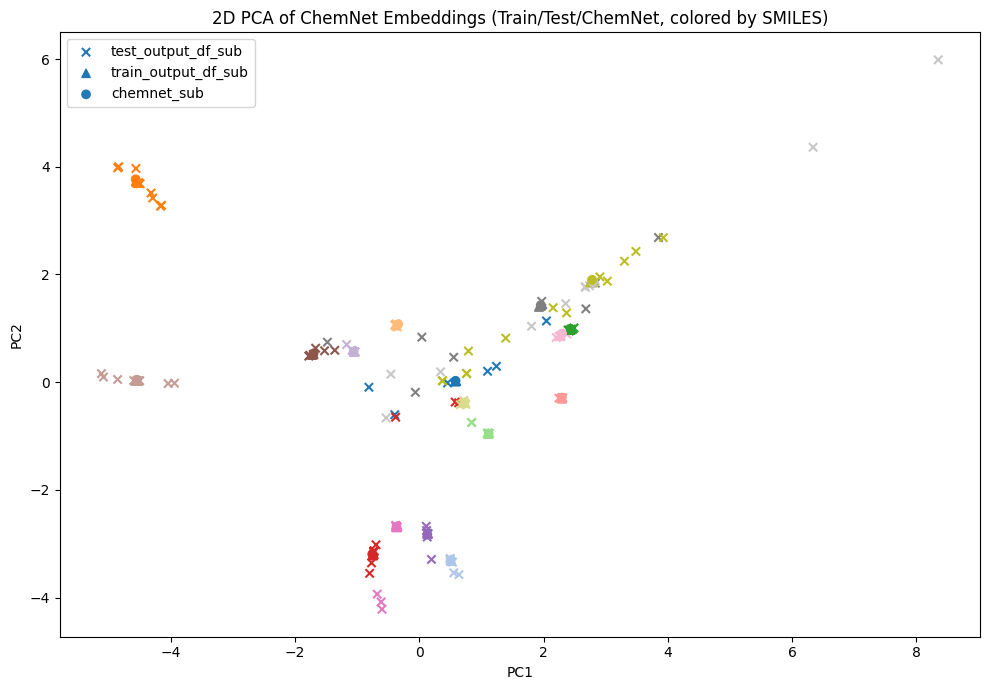

In [37]:
# PCA plot, color by SMILES (with train data plotted)

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split 
X_test_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Assign colors to unique SMILES
all_smiles = pd.concat([
    test_output_df_sub['SMILES_spectra'],
    train_output_df_sub['SMILES_spectra'],
    chemnet_sub['SMILES']
]).unique()
color_map = {smiles: cm.tab20(i % 20) for i, smiles in enumerate(all_smiles)}

output_colors = test_output_df_sub['SMILES_spectra'].map(color_map)
train_colors = train_output_df_sub['SMILES_spectra'].map(color_map)
chemnet_colors = chemnet_sub['SMILES'].map(color_map)

# Plot
plt.figure(figsize=(10,7))

plt.scatter(X_output_pca[:,0], X_output_pca[:,1], 
            c=output_colors, marker='x', label='test_output_df_sub', alpha=0.99)
plt.scatter(X_train_output_pca[:,0], X_train_output_pca[:,1], 
            c=train_colors, marker='^', label='train_output_df_sub', alpha=0.99)
plt.scatter(X_chemnet_pca[:,0], X_chemnet_pca[:,1], 
            c=chemnet_colors, marker='o', label='chemnet_sub', alpha=0.99)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test/ChemNet, colored by SMILES)')
plt.tight_layout()
plt.legend()
plt.show()

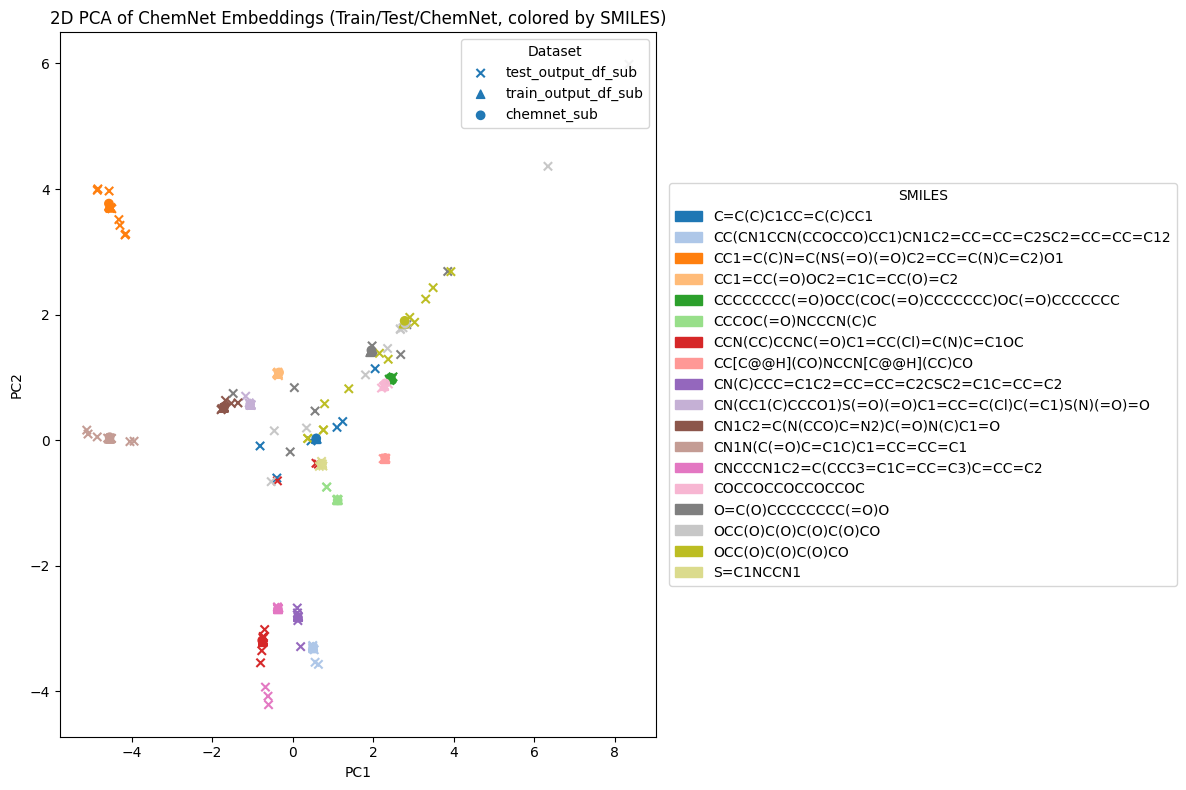

In [38]:
# PCA plot, color by SMILES (with train data plotted and SMILES legend)

# Prepare data
emb_cols_test_output = get_embedding_columns(test_output_df_sub)
emb_cols_train_output = get_embedding_columns(train_output_df_sub)
emb_cols_chemnet = get_embedding_columns(chemnet_sub)

# Get the actual data as numpy arrays
X_test_output = test_output_df_sub[emb_cols_test_output].values
X_train_output = train_output_df_sub[emb_cols_train_output].values
X_chemnet = chemnet_sub[emb_cols_chemnet].values

# Combine for PCA fit
X_all = np.vstack([X_test_output, X_train_output, X_chemnet])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

# Re-split
X_test_output_pca = X_all_pca[:len(test_output_df_sub)]
X_train_output_pca = X_all_pca[len(test_output_df_sub):len(test_output_df_sub) + len(train_output_df_sub)]
X_chemnet_pca = X_all_pca[len(test_output_df_sub) + len(train_output_df_sub):]

# Assign colors to unique SMILES
all_smiles = pd.concat([
    test_output_df_sub['SMILES_spectra'],
    train_output_df_sub['SMILES_spectra'],
    chemnet_sub['SMILES']
]).unique()
color_map = {smiles: cm.tab20(i % 20) for i, smiles in enumerate(all_smiles)}

test_output_colors = test_output_df_sub['SMILES_spectra'].map(color_map)
train_colors = train_output_df_sub['SMILES_spectra'].map(color_map)
chemnet_colors = chemnet_sub['SMILES'].map(color_map)

plt.figure(figsize=(12,8))

plt.scatter(X_test_output_pca[:,0], X_test_output_pca[:,1], 
            c=test_output_colors, marker='x', label='test_output_df_sub', alpha=0.99)
plt.scatter(X_train_output_pca[:,0], X_train_output_pca[:,1], 
            c=train_colors, marker='^', label='train_output_df_sub', alpha=0.99)
plt.scatter(X_chemnet_pca[:,0], X_chemnet_pca[:,1], 
            c=chemnet_colors, marker='o', label='chemnet_sub', alpha=0.99)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA of ChemNet Embeddings (Train/Test/ChemNet, colored by SMILES)')

# First legend: dataset markers (handles only)
handles, labels = plt.gca().get_legend_handles_labels()
legend1 = plt.legend(handles, labels, loc='upper right', title='Dataset')

# Second legend: SMILES color mapping (show up to 20 for clarity)
max_smiles_legend = 20
smiles_legend_patches = [
    mpatches.Patch(color=color_map[smiles], label=smiles)
    for i, smiles in enumerate(all_smiles[:max_smiles_legend])
]
legend2 = plt.legend(handles=smiles_legend_patches, title="SMILES", loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.gca().add_artist(legend1)  # Add the first legend back

plt.tight_layout()
plt.show()

## Random Forest on Spectra

In [41]:
# Load the needed packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score


In [42]:
print(train_output_df.shape)
print(test_output_df.shape)
print(ChemNet_of_df3_QQpos_no_repeats.shape)

(609, 514)
(579, 514)
(257, 513)
